# The Modern AMPL Stack: Hands on

Welcome to the hands-on portion of our webinar! In this notebook, we will transition a classic optimization problem (The Diet Problem) from the legacy standalone IDE into a modern Python environment. 

By integrating AMPL with Python, we move away from rigid `.dat` and `.run` files and unlock the full power of data science tools (like Pandas for data manipulation and Matplotlib for visualization), as well as the vastly used python development ecosystem.

## 1. Installation & Setup

In a modern cloud environment like Google Colab, there is no "install fatigue" for your students. Everything is set up in seconds using standard Python package managers.

In [10]:
# Install the AMPL Python API (other libraries are installed by default in Google colab)
!pip install -q amplpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 2. Import Libraries and Activate License

We import `amplpy` and activate our license and solver modules.

It is important to note that the process can change slightly between the google colab environment and a pure python set up. During the webinar we'll explore both options but a *Quick Start* guide can be consulted [here](https://amplpy.ampl.com/en/latest/#installation-minimal-example).

At this point a license UUID will generally be required. However, when working from colab the keyword `default` may be input toa ctivate a generic community edition license with access to open-source solvers only.

To get a valid academic license the process, go to the [portal website](https://portal.ampl.com/account/ampl/).

In [ ]:
from amplpy import ampl_notebook
import pandas as pd
import matplotlib.pyplot as plt

ampl = ampl_notebook(
    modules=["highs", "cplex", "gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

## 3. The Diet Problem

The goal of the model is to find the cheapest combination of a fixed set of foods that satisfies all nutritional requirements for a week.

### Sets
*   $N$: Set of nutrients (`NUTR`)
*   $F$: Set of foods (`FOOD`)

### Parameters
*   $c_j$: Cost per unit of food $j \in F$
*   $f_{min,j}$: Minimum units of food $j \in F$
*   $f_{max,j}$: Maximum units of food $j \in F$
*   $n_{min,i}$: Minimum requirement for nutrient $i \in N$
*   $n_{max,i}$: Maximum allowance for nutrient $i \in N$
*   $a_{i,j}$: Amount of nutrient $i$ per unit of food $j$

### Decision Variables
*   $x_j$: Units of food $j$ to purchase, $x_j \in \mathbb{Z}^+$ (Integer)

### Objective Function
Minimize the total cost of the diet:
$$\min Z = \sum_{j \in F} c_j x_j$$

### Constraints
1.  **Nutritional Requirements:** For each nutrient $i \in N$, the total intake must fall within the specified bounds:
    $$n_{min,i} \leq \sum_{j \in F} a_{i,j} x_j \leq n_{max,i}, \quad \forall i \in N$$

2.  **Food Bounds:** For each food $j \in F$, the quantity purchased must be within limits:
    $$f_{min,j} \leq x_j \leq f_{max,j}, \quad \forall j \in F$$

Instead of writing the model within an IDE, we can keep the exact same `.mod` file logic. This honors your existing teaching materials while upgrading the engine that runs them. Additionally, if you're using Visual Studio Code, you can leverage the available extension to create the file with the same advantages as the IDE such as syntax highlighting.

Note that if you're working in python directly you'd simply need the path to the previously created model file. In colab's case, you can wither upload the file or create it using the *magic command*.

In [ ]:
%%writefile diet.mod
# Diet problem in AMPL

### SETS
set NUTR;
set FOOD;

### PARAMETERS
param cost {FOOD} > 0;
param f_min {FOOD} >= 0;
param f_max {j in FOOD} >= f_min[j];
param n_min {NUTR} >= 0;
param n_max {i in NUTR} >= n_min[i];
param amt {NUTR,FOOD} >= 0;

### VARIABLES
var Buy {j in FOOD} integer >= f_min[j], <= f_max[j];

### OBJECTIVE FUNCTION
minimize Total_Cost: sum {j in FOOD} cost[j] * Buy[j];

### CONSTRAINTS
subject to Diet {i in NUTR}:
    n_min[i] <= sum {j in FOOD} amt[i,j] * Buy[j] <= n_max[i];

## 4. Avoiding the `.dat` file

Instead of manually formatting text in a `.dat` file, we'll be using Pandas DataFrames. 

Keep in mind that this data could be dynamically pulled from an SQL database, an API, or an Excel file.

There is a possibility of reading the `.dat` file thorugh the function `ampl.read_data("diet.dat")`. However, the use of more robust data sources is encouraged.

In [15]:
# 1. Food Data (cost, min, max)
food_data = {
    'FOOD': ['BEEF', 'CHK', 'FISH', 'HAM', 'MCH', 'MTL', 'SPG', 'TUR'],
    'cost': [3.19, 2.59, 2.29, 2.89, 1.89, 1.99, 1.99, 2.49],
    'f_min': [2, 2, 2, 2, 2, 2, 2, 2],
    'f_max': [10, 10, 10, 10, 10, 10, 10, 10]
}
df_food = pd.DataFrame(food_data).set_index('FOOD')

# 2. Nutrition Data (min, max)
nutr_data = {
    'NUTR': ['A', 'C', 'B1', 'B2', 'NA', 'CAL'],
    'n_min': [700, 700, 700, 700, 0, 16000],
    'n_max': [20000, 20000, 20000, 20000, 50000, 24000]
}
df_nutr = pd.DataFrame(nutr_data).set_index('NUTR')

# 3. Amount Data (Nutrition per Food)
amt_data = {
    'FOOD': ['BEEF', 'CHK', 'FISH', 'HAM', 'MCH', 'MTL', 'SPG', 'TUR'],
    'A': [60, 8, 8, 40, 15, 70, 25, 60],
    'C': [20, 0, 10, 40, 35, 30, 50, 20],
    'B1': [10, 20, 15, 35, 15, 15, 25, 15],
    'B2': [15, 20, 10, 10, 15, 15, 15, 10],
    'NA': [938, 2180, 945, 278, 1182, 896, 1329, 1397],
    'CAL': [295, 770, 440, 430, 315, 400, 370, 450]
}
# We melt/stack the data to match the 2D parameter structure in AMPL: param amt {NUTR,FOOD}
df_amt = pd.DataFrame(amt_data).melt(id_vars='FOOD', var_name='NUTR', value_name='amt')
df_amt = df_amt.set_index(['NUTR', 'FOOD'])

## 5. Loading Data and Solving


Having the `ampl` object already created, we can proceed with loading the data to the model and replacing the rest of the commands written in the `.run` file.

The `amplpy` library is versatile in providing several ways to achieve these steps, allowing the user to choose the one that best fits her needs.

In [ ]:
# Sanity reset (`reset;`)
ampl.reset()

# Load the model (`model diet.mod;`)
ampl.read('diet.mod')

# Push Pandas DataFrames directly into AMPL sets and parameters (`data diet.dat;`)
ampl.set_data(df_food, 'FOOD')
ampl.set_data(df_nutr, 'NUTR')
ampl.set_data(df_amt)

# Configure the solver (using the open-source HiGHS solver) (`option solver highs;`)
ampl.option["solver"] = "highs"

# Solve the model (`solve;`)
ampl.solve()

HiGHS 1.11.0HiGHS 1.11.0: optimal solution; objective 119.3
14 simplex iterations
1 branching nodes


## 6. Extracting Results

The last command of the `.run` file displays a decision variable of the model. Besided querying the value we can store it in pandas data structures to further processing and use.

In [23]:
# Get the total cost objective
total_cost = ampl.get_objective('Total_Cost').value()
print(f"Optimal Diet Cost: ${total_cost:.2f}\n")

# Extract the 'Buy' variable as a Pandas DataFrame
df_results = ampl.get_variable('Buy').get_values().to_pandas()
df_results.columns = ['Buy']

print(df_results)

Optimal Diet Cost: $119.30

      Buy
BEEF    9
CHK     2
FISH    2
HAM     8
MCH    10
MTL    10
SPG     7
TUR     2


Just as before, there are several ways of getting the results and data from the model. The most general form would be to use the `.get_data` function.

In [24]:
ampl.get_data("Diet.lb, Diet.body, Diet.ub;").to_pandas()

,Diet.lb,Diet.body,Diet.ub
A,700,2037,20000
B1,700,945,20000
B2,700,700,20000
C,700,1560,20000
CAL,16000,19155,24000
NA,0,49793,50000


## 7. Visualization

Working directly in python, allows to easily showcase the results and impact of changes in data graphically. Moreover, plotting functions can defined to be reused later on.

In [34]:
def plot_optimal_diet(df):
    df.plot(kind='bar', color='skyblue', edgecolor='black', legend=False)
    plt.title('Optimal Diet Plan')
    plt.ylabel('Amount to Buy')
    plt.xlabel('Food Item')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

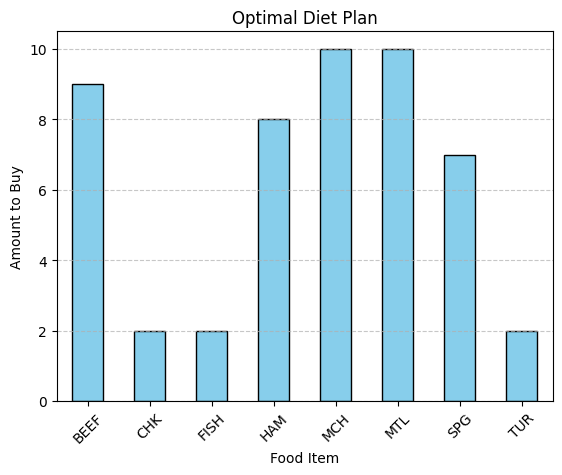

In [35]:
plot_optimal_diet(df_results)

## 8. Dynamic Interaction: Changing Data and Solvers

Performing "What-If" analysis is now trivial. 

What if the cost of Beef skyrockets due to inflation?

What if the maximum quantity of some nutrient is lower and the model becomes infeasible?

Can we test a commercial solver like CPLEX or Gurobi?


Scenario: Beef price increases to $10.00
HiGHS 1.11.0HiGHS 1.11.0: optimal solution; objective 160.65
6 simplex iterations
1 branching nodes


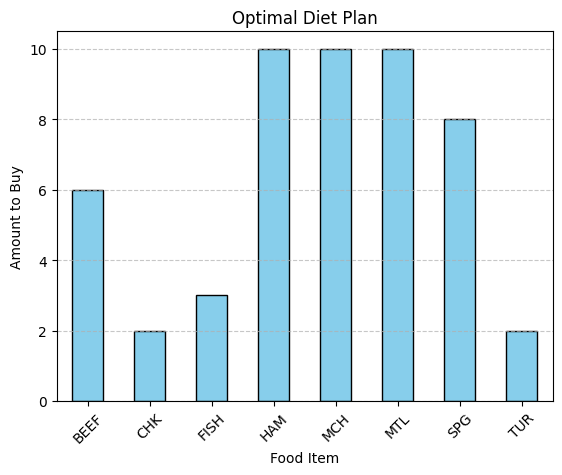

In [40]:
print("Scenario: Beef price increases to $10.00")

# Update the parameter directly in the AMPL instance
ampl.get_parameter('cost')['BEEF'] = 10.00

# Re-solve
ampl.solve()

# Fetch and display the new results
df_new_results = pd.DataFrame.from_dict(ampl.get_solution(flat=False))

plot_optimal_diet(df_new_results)

In [ ]:
print("Scenario: NA maximum requirement changes")

# Reset BEEF price
ampl.param['cost']['BEEF'] = 3.19

# Change NA maximum requirement
ampl.param['n_max']['NA'] = 40000

# Change solver and re-solve
ampl.option["solver"] = 'gurobi'
ampl.solve()


Scenario: NA maximum requirement changes
Gurobi 13.0.1:   iis:find = 1
  iis:find = 1
Gurobi 13.0.1: infeasible problem
0 simplex iterations
The model is infeasible under the new NA requirement.
Gurobi 13.0.1:   iis:find = 1
Gurobi 13.0.1: Unknown option or invalid key "iis_table"
    Diet.iis
A        non
B1       non
B2       mem
C        non
CAL      non
NA       mem


In [ ]:
if ampl.solve_result == 'infeasible':
    print("The model is infeasible under the new NA requirement.")
    # Since using Gurobi, we can get IIS to diagnose the infeasibility
    ampl.option["mp_options"] = "iis=1"
    ampl.solve()
    iis = ampl.get_data('Diet.iis').to_pandas()
    print(iis)

In [55]:
print(ampl.option["iis_table"])


0	non	not in the iis
1	low	lower bound in the iis
2	fix	both bounds in the iis
3	upp	upper bound in the iis
4	mem	member
5	pmem	possible member
6	plow	possibly lower bound
7	pupp	possibly upper bound
8	bug



## 9. Advanced Analysis: Duals and Sensitivity

When treating LP problems, duality concepts are key in most courses. AMPL allows to access dual values to ease the interpretation.

In [58]:
# Reset to avoid conflicts from previous sections
ampl.reset()

# Load the model (`model diet.mod;`)
ampl.read('diet.mod')

# Push Pandas DataFrames directly into AMPL sets and parameters (`data diet.dat;`)
ampl.set_data(df_food, 'FOOD')
ampl.set_data(df_nutr, 'NUTR')
ampl.set_data(df_amt)

# Configure the solver (using the open-source HiGHS solver) (`option solver highs;`)
ampl.eval("reset options;")
dct_options = {
    "relax_integrality": 1,
    "solver": "highs",
}
for k, v in dct_options.items():
    ampl.set_option(k, v)

# Solve the model (`solve;`)
ampl.solve()

HiGHS 1.11.0HiGHS 1.11.0: optimal solution; objective 118.0594032
5 simplex iterations
0 barrier iterations


In [61]:
ampl.get_data("Diet.dual, Diet.lb, Diet.body, Diet.ub;").to_pandas()

,Diet.dual,Diet.lb,Diet.body,Diet.ub
A,0.000000,700,1956.288150,20000
B1,0.000000,700,1036.257460,20000
B2,0.404585,700,700.000000,20000
C,0.000000,700,1682.514919,20000
CAL,0.000000,16000,19794.620631,24000
NA,-0.003069,0,50000.000000,50000


## 10. Additional Resources

You cand find [here](https://ampl.com/resources/) all the available resources. Don't forget to check:
*   **AMPL Model Colaboratory:** Explore a massive library of ready-to-run Jupyter Notebooks: [colab.ampl.com](https://colab.ampl.com/)
*   **AMPL Streamlit Apps:** interactive applications to explore the power of AMPL and optimization: [amplopt.streamlit.app](https://amplopt.streamlit.app/)
*   **AMPL Python API Documentation:** [amplpy.ampl.com](https://amplpy.ampl.com/)

## 11. Helpful functionalities

In this section, we describe and provide access to special functionalities we deem useful in the teaching process and in the transition towards a modern AMPL use. Namely:
* A python function that takes the `.dat` file and creates several `.csv` files with the information about sets and parameters
* Description of the snapshot feature, that can export a model with all its relevant and current information (data, options, etc.)
* Description of `ampls`, our special libraries to interact directly with more advanced solver's functionalities such as defining custom callbacks.


### 11.1 From `.dat` to `.csv`

As mentioned, the following function can be used to quickly convert a `.dat` file into several `.csv` or `.xlsx` files. The main drawback is that the resulting files may not be the most efficient way to store the data. For instance, if several parameters shared indexation they could be merged into one single table or spreadsheet. However, the function is generic so it works with any `.dat` file and model.

*Note:* to use it correctly, the `amplpy` and `pandas` libraries must be installed. Additionally, the accompanying `.mod` file must be provided for the data to be processed correctly.

In [77]:
import os
import pandas as pd
from amplpy import AMPL

def export_ampl_data(mod_file, dat_file, output_path="ampl_data.xlsx"):
    """
    Reads an AMPL model and .dat file and exports all sets and parameters.
    
    - If output_path ends in '.xlsx', it generates a single Excel workbook with multiple sheets.
    - Otherwise, it treats output_path as a directory name and generates multiple CSV files inside it.
    """
    ampl = AMPL()
    try:
        # Load the model and the legacy data file
        ampl.read(mod_file)
        ampl.read_data(dat_file)
    except Exception as e:
        print(f"Error loading files: {e}")
        return

    # Check if the desired output is Excel
    is_excel = output_path.lower().endswith(('.xlsx', '.xls'))

    if is_excel:
        print(f"Exporting data to Excel workbook: {output_path}...")
        # engine='xlsxwriter' is recommended for better formatting support if needed later
        with pd.ExcelWriter(output_path) as writer:
            
            # Export Sets
            for name, ampl_set in ampl.get_sets():
                df = ampl_set.get_values().to_pandas().reset_index()
                if not df.empty:
                    sheet_name = f"set_{name}"
                    df.to_excel(writer, sheet_name=sheet_name)
            
            # Export Parameters
            for name, param in ampl.get_parameters():
                df = param.get_values().to_pandas()
                if not df.empty:
                    sheet_name = f"param_{name}"
                    df.to_excel(writer, sheet_name=sheet_name)
                    
        print("Success! Excel migration complete.")

    else:
        # If the user explicitly wrote .csv, strip it to use as a clean folder name
        if output_path.lower().endswith('.csv'):
            output_path = output_path[:-4]
            
        os.makedirs(output_path, exist_ok=True)
        print(f"Exporting data to CSV folder: {output_path}/...")
        
        # Export Sets
        for name, ampl_set in ampl.get_sets():
            df = ampl_set.get_values().to_pandas()
            if not df.empty:
                file_path = os.path.join(output_path, f"set_{name}.csv")
                df.to_csv(file_path)
                
        # Export Parameters
        for name, param in ampl.get_parameters():
            df = param.get_values().to_pandas()
            if not df.empty:
                file_path = os.path.join(output_path, f"param_{name}.csv")
                df.to_csv(file_path)
                
        print("Success! CSV migration complete.")

In [ ]:
# --- Example Usage ---

# 1. Export to a single Excel file
export_ampl_data("diet.mod", "diet.dat", output_path="diet_data.xlsx")

# 2. Export to a folder full of CSVs
export_ampl_data("diet.mod", "diet.dat", output_path="diet_data")

Exporting data to Excel workbook: university_diet_data.xlsx...
Success! Excel migration complete.
Exporting data to CSV folder: university_diet_data_csvs/...
Success! CSV migration complete.


### 11.2 Snapshot feature

The snapshot feature allows a user to export an ampl session including the model declaration, loaded data and configured options. It is useful for warm starting new runs as showed in [this](https://ampl.com/colab/notebooks/warm-start-solvers-with-snapshot.html) example, but it could also aid in grading student's assignments.

Syntax documentation is presented [here](https://amplpy.ampl.com/en/latest/classes/ampl.html#amplpy.AMPL.snapshot).

In [11]:
from amplpy import AMPL

# Create ampl session
ampl = AMPL()

# Perform some ampl actions (loading model, data, solving, etc)
ampl.read('diet.mod')
ampl.read_data('diet.dat')
ampl.option['solver'] = 'highs'
ampl.solve()

# Export the complete ampl session
ampl.snapshot("ampl_diet_snapshot.run")  # Optionally select if model, data, and options are required.

HiGHS 1.11.0HiGHS 1.11.0: optimal solution; objective 119.3
14 simplex iterations
1 branching nodes


''

In [12]:
# Read back the ampl session
ampl = AMPL()
ampl.read("ampl_diet_snapshot.run")
ampl.option['solver']

'highs'

### 11.3 ampls

`ampls` is an open-source set of lightweight interfaces connecting AMPL directly to optimization solvers. Its primary use case is enabling advanced users and researchers to implement generic solver callbacks, which allow you to interact with the optimization engine while it is actively running. Through these callbacks, you can monitor the solver's progress, track explored nodes, and retrieve intermediate solutions. Most importantly, it empowers you to efficiently solve highly complex models by dynamically generating and injecting custom user cuts or lazy constraints on the fly during the solve process, rather than overwhelming the solver with millions of constraints upfront. An example regarding the TSP with subtour elimination can be found [here](https://ampl.com/colab/notebooks/travelling-salesman-problem-with-subtour-elimination.html).